# Final XGBoost model - Credit Card Fraud Detection

Clean notebook to train the selected XGBoost approach on the original dataset, tune the decision threshold on validation, evaluate on test, and save the chosen model.

In [7]:
# Imports and project paths

from pathlib import Path
import json
import os
import random

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
)

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "creditcard.csv"
MODEL_OUTPUT_DIR = PROJECT_ROOT / "models" / "xgboost_original_recall95_f1"
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH, MODEL_OUTPUT_DIR

(PosixPath('/Users/andreyvargassolis/Desktop/Data_Science/Credit_Card_Fraud/data/creditcard.csv'),
 PosixPath('/Users/andreyvargassolis/Desktop/Data_Science/Credit_Card_Fraud/models/xgboost_original_recall95_f1'))

In [8]:
# Load original dataset and create train / validation / test split

raw_data = pd.read_csv(DATA_PATH)

X = raw_data.drop("Class", axis=1)
y = raw_data["Class"]

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.20,
    random_state=SEED,
    stratify=y_train_val,
)

split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "rows": [len(y_train), len(y_val), len(y_test)],
    "frauds": [int(y_train.sum()), int(y_val.sum()), int(y_test.sum())],
    "non_frauds": [int((y_train == 0).sum()), int((y_val == 0).sum()), int((y_test == 0).sum())],
})

display(split_summary)

,split,rows,frauds,non_frauds
0,train,182276,315,181961
1,validation,45569,79,45490
2,test,56962,98,56864


In [ ]:
# Train XGBoost candidates and select the threshold with recall >= 90% and maximum fraud F1

target_recall = 0.90
base_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
pos_weight_multipliers = [1.0, 1.25, 1.5, 2.0, 3.0, 5.0, 8.0]

base_xgb_params = {
    "n_estimators": 700,
    "learning_rate": 0.03,
    "max_depth": 4,
    "min_child_weight": 3,
    "subsample": 0.80,
    "colsample_bytree": 0.80,
    "reg_lambda": 3.0,
    "reg_alpha": 0.10,
    "objective": "binary:logistic",
    "eval_metric": "aucpr",
    "random_state": SEED,
    "n_jobs": -1,
}

xgb_models = {}
model_rows = []
threshold_rows = []

for multiplier in pos_weight_multipliers:
    pos_weight = base_pos_weight * multiplier
    model_key = f"spw_x{multiplier:g}"

    xgb_model = XGBClassifier(
        **base_xgb_params,
        scale_pos_weight=pos_weight,
    )

    xgb_model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )

    xgb_models[model_key] = xgb_model

    val_prob = xgb_model.predict_proba(X_val)[:, 1]
    pr_auc = average_precision_score(y_val, val_prob)
    precision, recall, thresholds = precision_recall_curve(y_val, val_prob)

    precision_at_threshold = precision[:-1]
    recall_at_threshold = recall[:-1]
    positives_val = int((y_val == 1).sum())

    true_positives = np.rint(recall_at_threshold * positives_val).astype(int)
    false_negatives = positives_val - true_positives
    false_positives = np.zeros_like(true_positives)
    valid_precision_mask = precision_at_threshold > 0
    false_positives[valid_precision_mask] = np.rint(
        true_positives[valid_precision_mask] / precision_at_threshold[valid_precision_mask]
        - true_positives[valid_precision_mask]
    ).astype(int)
    f1_at_threshold = np.where(
        precision_at_threshold + recall_at_threshold > 0,
        2 * precision_at_threshold * recall_at_threshold / (precision_at_threshold + recall_at_threshold),
        0,
    )

    threshold_rows.extend(
        pd.DataFrame({
            "model_key": model_key,
            "multiplier": multiplier,
            "scale_pos_weight": pos_weight,
            "threshold": thresholds,
            "precision_fraud": precision_at_threshold,
            "recall_fraud": recall_at_threshold,
            "f1_fraud": f1_at_threshold,
            "false_positives": false_positives,
            "false_negatives": false_negatives,
            "true_positives": true_positives,
            "pr_auc": pr_auc,
        }).to_dict("records")
    )

    model_rows.append({
        "model_key": model_key,
        "multiplier": multiplier,
        "scale_pos_weight": pos_weight,
        "validation_pr_auc": pr_auc,
    })

model_summary_df = pd.DataFrame(model_rows).sort_values("validation_pr_auc", ascending=False)
thresholds_df = pd.DataFrame(threshold_rows)
valid_thresholds_df = thresholds_df[thresholds_df["recall_fraud"] >= target_recall]

if valid_thresholds_df.empty:
    print("No threshold reached recall >= 90% on validation. Selecting the closest option.")
    best_row = thresholds_df.sort_values(
        ["recall_fraud", "f1_fraud", "false_positives"],
        ascending=[False, False, True],
    ).iloc[0]
else:
    best_row = valid_thresholds_df.sort_values(
        ["f1_fraud", "false_positives", "precision_fraud", "pr_auc"],
        ascending=[False, True, False, False],
    ).iloc[0]

best_model = xgb_models[best_row["model_key"]]
best_threshold = float(best_row["threshold"])

display(model_summary_df.round(4))
display(
    valid_thresholds_df.sort_values(
        ["f1_fraud", "false_positives", "precision_fraud"],
        ascending=[False, True, False],
    )
    .head(15)
    .round(4)
)

print("Selected model:", best_row["model_key"])
print("Selected scale_pos_weight:", round(float(best_row["scale_pos_weight"]), 4))
print("Selected threshold:", best_threshold)
print("Validation recall fraud:", round(float(best_row["recall_fraud"]), 4))
print("Validation precision fraud:", round(float(best_row["precision_fraud"]), 4))
print("Validation F1 fraud:", round(float(best_row["f1_fraud"]), 4))
print("Validation false positives:", int(best_row["false_positives"]))
print("Validation PR-AUC:", round(float(best_row["pr_auc"]), 4))

,model_key,multiplier,scale_pos_weight,validation_pr_auc
3,spw_x2,2.00,1155.3079,0.8289
1,spw_x1.25,1.25,722.0675,0.8277
2,spw_x1.5,1.50,866.4810,0.8275
0,spw_x1,1.00,577.6540,0.8243
4,spw_x3,3.00,1732.9619,0.8217
5,spw_x5,5.00,2888.2698,0.8206
6,spw_x8,8.00,4621.2317,0.8202


,model_key,multiplier,scale_pos_weight,threshold,precision_fraud,recall_fraud,f1_fraud,false_positives,false_negatives,true_positives,pr_auc
314469,spw_x8,8.0,4621.2317,0.0072,0.0617,0.9114,0.1157,1094,7,72,0.8202
314468,spw_x8,8.0,4621.2317,0.0071,0.0617,0.9114,0.1156,1095,7,72,0.8202
314467,spw_x8,8.0,4621.2317,0.0071,0.0616,0.9114,0.1155,1096,7,72,0.8202
314466,spw_x8,8.0,4621.2317,0.0071,0.0616,0.9114,0.1154,1097,7,72,0.8202
314465,spw_x8,8.0,4621.2317,0.0071,0.0615,0.9114,0.1153,1098,7,72,0.8202
314464,spw_x8,8.0,4621.2317,0.0071,0.0615,0.9114,0.1152,1099,7,72,0.8202
314463,spw_x8,8.0,4621.2317,0.0071,0.0614,0.9114,0.1151,1100,7,72,0.8202
314462,spw_x8,8.0,4621.2317,0.0071,0.0614,0.9114,0.1150,1101,7,72,0.8202
314461,spw_x8,8.0,4621.2317,0.0071,0.0613,0.9114,0.1149,1102,7,72,0.8202
314460,spw_x8,8.0,4621.2317,0.0071,0.0613,0.9114,0.1148,1103,7,72,0.8202


Selected model: spw_x8
Selected scale_pos_weight: 4621.2317
Selected threshold: 0.007152053993195295
Validation recall fraud: 0.9114
Validation precision fraud: 0.0617
Validation F1 fraud: 0.1157
Validation false positives: 1094
Validation PR-AUC: 0.8202


Final test results
              precision    recall  f1-score   support

    No Fraud     0.9999    0.9751    0.9873     56864
       Fraud     0.0604    0.9286    0.1135        98

    accuracy                         0.9750     56962
   macro avg     0.5301    0.9518    0.5504     56962
weighted avg     0.9983    0.9750    0.9858     56962

Test PR-AUC: 0.8667
False positives: 1415
False negatives / fraudes escapados: 7
True positives / fraudes detectados: 91


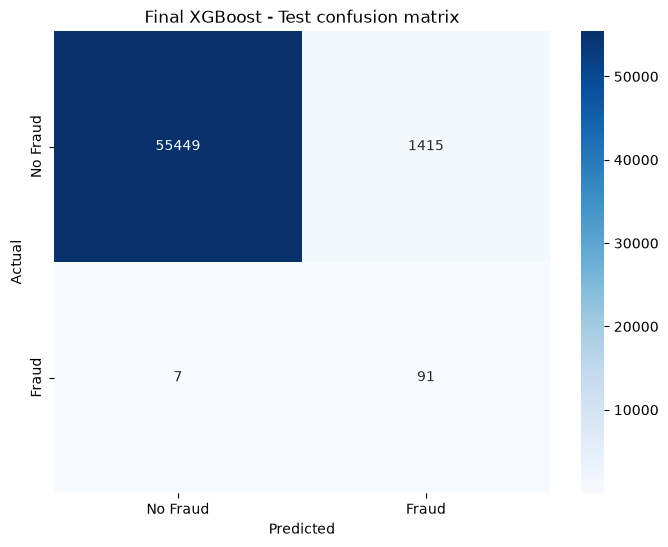

In [10]:
# Final test evaluation using the threshold selected on validation

test_prob = best_model.predict_proba(X_test)[:, 1]
test_pred = (test_prob >= best_threshold).astype(int)
test_cm = confusion_matrix(y_test, test_pred, labels=[0, 1])
tn, fp, fn, tp = test_cm.ravel()

test_metrics = {
    "precision_fraud": float(precision_score(y_test, test_pred, pos_label=1, zero_division=0)),
    "recall_fraud": float(recall_score(y_test, test_pred, pos_label=1, zero_division=0)),
    "f1_fraud": float(f1_score(y_test, test_pred, pos_label=1, zero_division=0)),
    "pr_auc": float(average_precision_score(y_test, test_prob)),
    "true_negatives": int(tn),
    "false_positives": int(fp),
    "false_negatives": int(fn),
    "true_positives": int(tp),
}

print("Final test results")
print(classification_report(
    y_test,
    test_pred,
    target_names=["No Fraud", "Fraud"],
    digits=4,
    zero_division=0,
))
print("Test PR-AUC:", round(test_metrics["pr_auc"], 4))
print("False positives:", test_metrics["false_positives"])
print("False negatives / fraudes escapados:", test_metrics["false_negatives"])
print("True positives / fraudes detectados:", test_metrics["true_positives"])

plt.figure(figsize=(8, 6))
sns.heatmap(
    test_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Fraud", "Fraud"],
    yticklabels=["No Fraud", "Fraud"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Final XGBoost - Test confusion matrix")
plt.show()

In [11]:
# Save the selected model, threshold, feature names, parameters, and metrics

model_joblib_path = MODEL_OUTPUT_DIR / "xgboost_original_recall95_f1.joblib"
model_json_path = MODEL_OUTPUT_DIR / "xgboost_original_recall95_f1.json"
metadata_path = MODEL_OUTPUT_DIR / "metadata.json"

selected_params = {
    **base_xgb_params,
    "scale_pos_weight": float(best_row["scale_pos_weight"]),
}

metadata = {
    "model_name": "xgboost_original_recall95_f1",
    "target_recall": target_recall,
    "selected_model_key": str(best_row["model_key"]),
    "selected_threshold": best_threshold,
    "selected_params": selected_params,
    "validation_metrics": {
        "precision_fraud": float(best_row["precision_fraud"]),
        "recall_fraud": float(best_row["recall_fraud"]),
        "f1_fraud": float(best_row["f1_fraud"]),
        "false_positives": int(best_row["false_positives"]),
        "false_negatives": int(best_row["false_negatives"]),
        "true_positives": int(best_row["true_positives"]),
        "pr_auc": float(best_row["pr_auc"]),
    },
    "test_metrics": test_metrics,
    "feature_names": X.columns.tolist(),
    "split": {
        "test_size": 0.20,
        "validation_size_from_train_val": 0.20,
        "random_state": SEED,
        "stratified": True,
    },
}

joblib.dump(
    {
        "model": best_model,
        "threshold": best_threshold,
        "feature_names": X.columns.tolist(),
        "metadata": metadata,
    },
    model_joblib_path,
)
best_model.save_model(model_json_path)
metadata_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

print("Saved model bundle:", model_joblib_path)
print("Saved native XGBoost model:", model_json_path)
print("Saved metadata:", metadata_path)

Saved model bundle: /Users/andreyvargassolis/Desktop/Data_Science/Credit_Card_Fraud/models/xgboost_original_recall95_f1/xgboost_original_recall95_f1.joblib
Saved native XGBoost model: /Users/andreyvargassolis/Desktop/Data_Science/Credit_Card_Fraud/models/xgboost_original_recall95_f1/xgboost_original_recall95_f1.json
Saved metadata: /Users/andreyvargassolis/Desktop/Data_Science/Credit_Card_Fraud/models/xgboost_original_recall95_f1/metadata.json
